In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
df = pd.read_csv("quikr_car.csv")

df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [ ]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

(892, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB
None
name           0
company        0
year           0
Price          0
kms_driven    52
fuel_type     55
dtype: int64


In [ ]:
df = df.dropna()

In [ ]:
df = df[df['year'].str.isnumeric()]

df['year'] = df['year'].astype(int)

In [ ]:
df = df[df['Price'] != 'Ask For Price']

df['Price'] = df['Price'].str.replace(',', '')

df['Price'] = df['Price'].astype(int)

In [ ]:
df['kms_driven'] = df['kms_driven'].str.replace(',', '')

df['kms_driven'] = df['kms_driven'].str.split().str[0]

df = df[df['kms_driven'].str.isnumeric()]

df['kms_driven'] = df['kms_driven'].astype(int)

In [ ]:
print(df.describe())

              year         Price     kms_driven
count   816.000000  8.160000e+02     816.000000
mean   2012.444853  4.117176e+05   46275.531863
std       4.002992  4.751844e+05   34297.428044
min    1995.000000  3.000000e+04       0.000000
25%    2010.000000  1.750000e+05   27000.000000
50%    2013.000000  2.999990e+05   41000.000000
75%    2015.000000  4.912500e+05   56818.500000
max    2019.000000  8.500003e+06  400000.000000


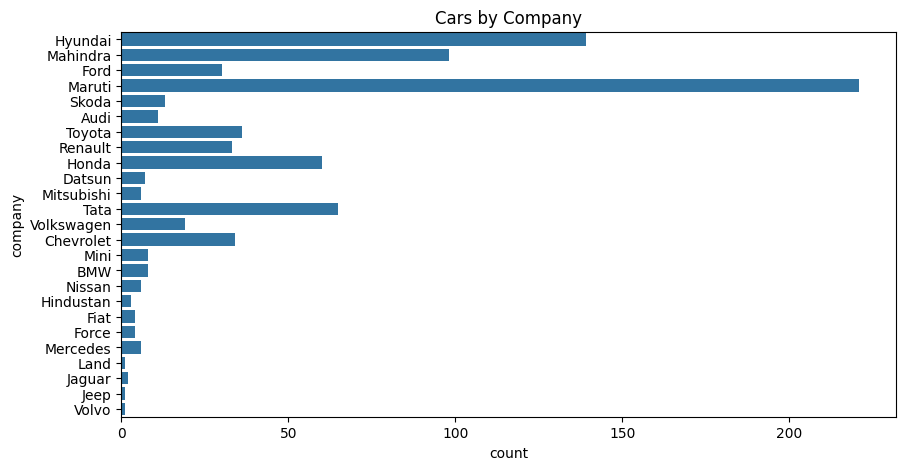

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(y=df['company'])

plt.title("Cars by Company")

plt.show()

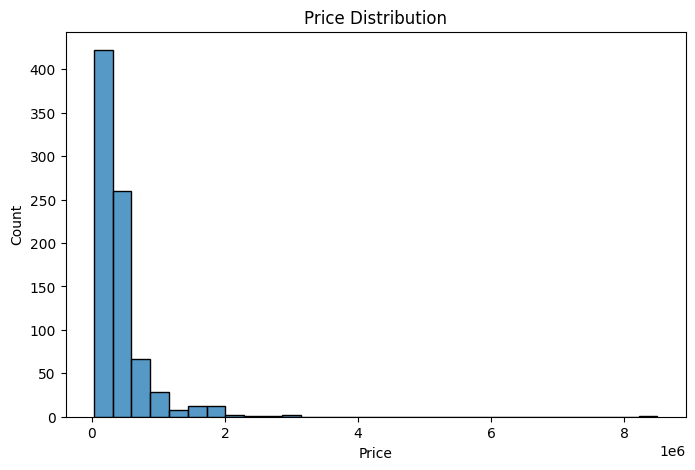

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Price'], bins=30)

plt.title("Price Distribution")

plt.show()

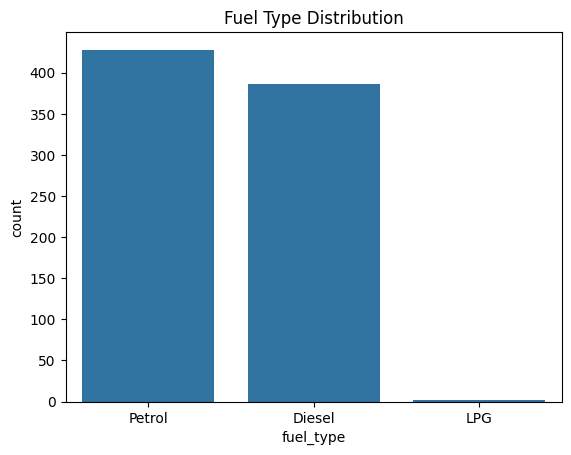

In [ ]:
sns.countplot(x='fuel_type', data=df)

plt.title("Fuel Type Distribution")

plt.show()

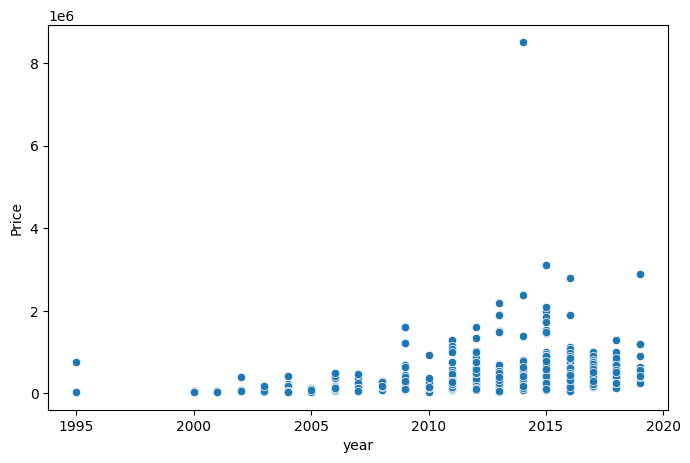

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='year', y='Price', data=df)

plt.show()

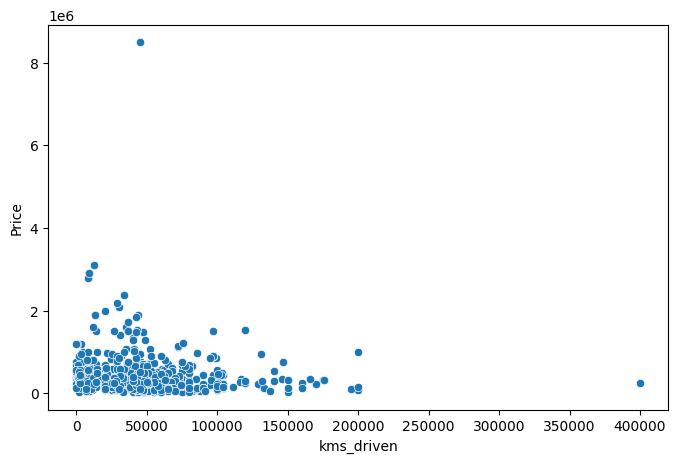

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='kms_driven', y='Price', data=df)

plt.show()

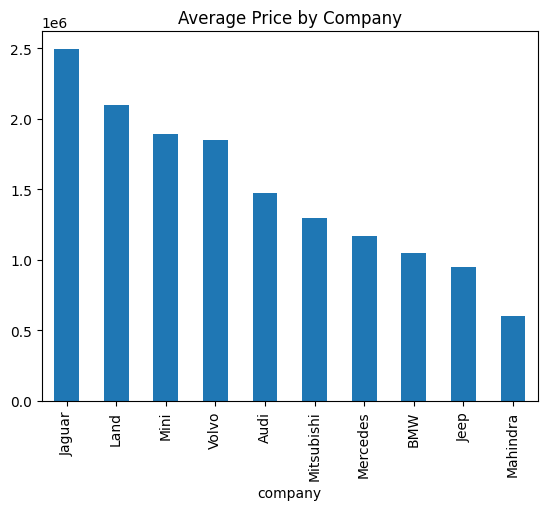

In [ ]:
avg_price = df.groupby('company')['Price'].mean()

avg_price.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Average Price by Company")

plt.show()

In [ ]:
X = df[['name',
        'company',
        'year',
        'kms_driven',
        'fuel_type']]

y = df['Price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
ohe = OneHotEncoder()

ohe.fit(X[['name',
           'company',
           'fuel_type']])

OneHotEncoder()

In [ ]:
column_trans = ColumnTransformer(
    [('ohe',
      OneHotEncoder(handle_unknown='ignore'),
      ['name', 'company', 'fuel_type'])],
    remainder='passthrough'
)

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt'
)

pipe = Pipeline([
    ('transformer', column_trans),
    ('model', rf)
])

In [ ]:
pipe.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['name', 'company',
                                                   'fuel_type'])])),
                ('model',
                 RandomForestRegressor(max_features='sqrt', n_estimators=500,
                                       random_state=42))])

In [ ]:
y_pred = pipe.predict(X_test)

In [ ]:
print("MAE =", mean_absolute_error(y_test, y_pred))

print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score =", r2_score(y_test, y_pred))

MAE = 175340.1243701123
RMSE = 676172.6566380328
R2 Score = 0.1823679898579863


In [ ]:
pipe.predict(pd.DataFrame({
    'name':['Maruti Suzuki Alto 800 Vxi'],
    'company':['Maruti'],
    'year':[2018],
    'kms_driven':[30000],
    'fuel_type':['Petrol']
}))

array([269565.966])

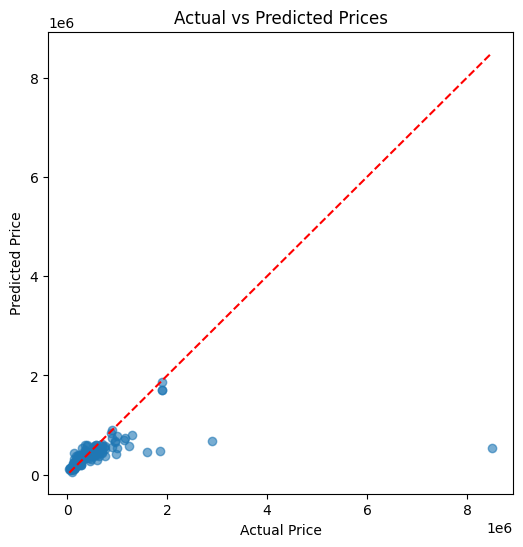

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()